# Explainable Arabic Sentiment Analysis: Comparing Classical NLP with Arabic Transformer-Based Models

## Introduction

Sentiment analysis identifies whether a text expresses a positive or negative opinion. Arabic social-media text introduces additional challenges because it contains dialectal expressions, spelling variation, informal wording, character elongation, hashtags, mentions, and emojis.

This project compares two approaches for binary Arabic sentiment classification: **TF-IDF + Logistic Regression** as a classical baseline and **MARBERT** as an Arabic Transformer model. MARBERT was pretrained on Arabic text with an emphasis on Modern Standard Arabic and dialectal Arabic, including Arabic tweets. This makes it a suitable candidate for a social-media sentiment experiment. [1]

The workflow audits the dataset, resolves duplicate texts and conflicting labels, applies conservative Arabic normalization, and constructs new train, validation, and test partitions with no shared cleaned texts. Both models use the same partitions and are assessed with the same metrics. Error analysis, feature interpretation, and uncertainty analysis are used to look beyond a single accuracy score.

**Important data decision:** the dataset's published training and test splits were found to contain repeated texts across splits, including some texts with different labels. The notebook therefore combines the original splits for data-quality auditing and reconstructs new partitions after resolving these issues. The final test set is a new hold-out partition, not the dataset provider's original test split.

# Research Objectives

1. Inspect the structure and label distribution of the Arabic sentiment corpus.
2. Audit missing text, duplicate texts, cross-split overlap, and inconsistent sentiment labels.
3. Apply conservative Arabic text normalization while preserving sentiment-bearing information.
4. Create stratified train, validation, and test sets with no shared normalized text.
5. Develop a TF-IDF + Logistic Regression baseline.
6. Fine-tune MARBERT for binary Arabic sentiment classification.
7. Compare both approaches using Accuracy, Precision, Recall, F1-score, ROC-AUC, Average Precision, and Balanced Accuracy.
8. Examine class-wise errors and confusion matrices.
9. Interpret the most influential TF-IDF features.
10. Analyze examples where the two models disagree and compare results by text length.
11. Estimate uncertainty in the test F1 difference with paired bootstrap resampling.
12. Discuss the results and limitations without assuming in advance that the Transformer must perform better.

# Research Question

> **How does contextual Arabic language representation affect sentiment classification compared with a traditional TF-IDF-based approach?**

The findings apply to the selected corpus, normalization procedure, partitions, and configurations—not automatically to every Arabic dialect or text domain.

# Dataset and Raw Data Source

**Dataset:** Arabic Sentiment Twitter Corpus  
**Hugging Face identifier:** `asas-ai/Arabic_Sentiment_Twitter_Corpus`  
**Dataset page:** https://huggingface.co/datasets/asas-ai/Arabic_Sentiment_Twitter_Corpus  
**Original source linked by the dataset card:** https://www.kaggle.com/datasets/mksaad/arabic-sentiment-twitter-corpus  
**Text column:** `tweet`  
**Label column:** `label`  
**Expected labels:** `neg` and `pos`

The dataset card currently reports 56,795 observations across its published splits. Actual row counts and columns are inspected from the downloaded data.

**MARBERT model:** `UBC-NLP/MARBERT`  
Model card: https://huggingface.co/UBC-NLP/MARBERT

MARBERT was developed for both dialectal Arabic and Modern Standard Arabic, with pretraining on a large corpus of Arabic tweets. [1]

# Methodology

```text
Arabic Sentiment Corpus
        ↓
Dataset Quality Audit
        ↓
Raw Duplicate / Overlap / Label Conflict Checks
        ↓
Arabic Cleaning and Normalization
        ↓
Post-Cleaning Conflict Check and Deduplication
        ↓
Exploratory Data Analysis
        ↓
Stratified 70/15/15 Split
        ↓
Final Text-Overlap Verification
        ↓
TF-IDF + Logistic Regression  ↔  MARBERT
        ↓
Validation and Held-Out Test Comparison
        ↓
Confusion Matrices and Error Analysis
        ↓
TF-IDF Feature Interpretation
        ↓
Bootstrap F1 Difference and Length Subgroups
        ↓
Results, Discussion, and Conclusion
```

**Scientific controls:** TF-IDF is fitted only on training texts; MARBERT is fine-tuned only on training data; validation is used for comparison; and the test partition is used only for final evaluation.

# Environment Setup

Run the notebook from top to bottom in Google Colab. A GPU runtime is recommended for MARBERT fine-tuning.

In [1]:
%pip -q install -U datasets transformers accelerate scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 604.4/604.4 kB 20.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 100.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 100.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 17.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
cudf-cu13 26.6.0 requires pyarrow<24,>=19.0.0, but you have pyarrow 25.0.1 which is incompatible.


# Import Libraries and Define Configuration

All shared functions and label mappings are defined near the beginning of the notebook so later cells will not fail because a helper function has not yet been executed.

In [2]:
import os
import re
import time
import inspect
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from datasets import load_dataset, Dataset
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, balanced_accuracy_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    RocCurveDisplay, PrecisionRecallDisplay
)
import torch
from scipy.special import softmax
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    DataCollatorWithPadding, TrainingArguments, Trainer
)

warnings.filterwarnings("ignore", category=FutureWarning)
RANDOM_STATE = 42
TEXT_COLUMN = "tweet"
LABEL_COLUMN = "label"
MODEL_NAME = "UBC-NLP/MARBERT"
MAX_LENGTH = 128
NUM_TRAIN_EPOCHS = 2

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_STATE)

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 160)

print("Libraries imported successfully.")
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("A GPU is recommended for faster MARBERT fine-tuning.")

def normalize_label(value):
    value = str(value).strip().lower()
    if value in {"neg", "negative", "0"}:
        return "neg"
    if value in {"pos", "positive", "1"}:
        return "pos"
    raise ValueError(f"Unexpected sentiment label: {value}")

def encode_label(value):
    return 0 if normalize_label(value) == "neg" else 1

URL_PATTERN = re.compile(r"https?://\S+|www\.\S+", flags=re.IGNORECASE)
MENTION_PATTERN = re.compile(r"(?<!\w)@[\w\u0600-\u06FF]+", flags=re.UNICODE)
ZERO_WIDTH_PATTERN = re.compile(r"[\u200B-\u200F\uFEFF]")
TATWEEL_PATTERN = re.compile(r"ـ")
ALEF_VARIANTS_PATTERN = re.compile(r"[إأآٱ]")
MULTISPACE_PATTERN = re.compile(r"\s+")

def clean_arabic_text(text):
    """Conservatively normalize Arabic social-media text."""
    if pd.isna(text):
        return ""
    text = str(text)
    text = URL_PATTERN.sub(" ", text)
    text = MENTION_PATTERN.sub(" ", text)
    text = ZERO_WIDTH_PATTERN.sub("", text)
    text = TATWEEL_PATTERN.sub("", text)
    text = ALEF_VARIANTS_PATTERN.sub("ا", text)
    text = text.replace("ى", "ي")
    text = text.replace("#", " ")
    text = MULTISPACE_PATTERN.sub(" ", text).strip()
    return text

def classification_metrics(y_true, y_pred, positive_probability):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    positive_probability = np.asarray(positive_probability)
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_true, positive_probability),
        "Average Precision": average_precision_score(y_true, positive_probability),
        "Balanced Accuracy": balanced_accuracy_score(y_true, y_pred)
    }

print("Arabic text cleaning, label encoding, and evaluation functions are ready.")

Libraries imported successfully.
PyTorch version: 2.11.0+cu130
CUDA available: True
GPU: Tesla T4
Arabic text cleaning, label encoding, and evaluation functions are ready.


# Load the Dataset

In [3]:
DATASET_ID = "asas-ai/Arabic_Sentiment_Twitter_Corpus"
dataset = load_dataset(DATASET_ID)
print(dataset)
print("Available splits:", list(dataset.keys()))

README.md:   0%|          | 0.00/727 [00:00<?, ?B/s]

data/train-00000-of-00001-be509c50eead48(…): reconstructing file:   0%|          |  0.00B / 3.15MB            

data/train-00000-of-00001-be509c50eead48(…): downloading bytes:           |  0.00B            

data/test-00000-of-00001-3b8479288762201(…): reconstructing file:   0%|          |  0.00B /  789kB            

data/test-00000-of-00001-3b8479288762201(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/45275 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/11520 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['label', 'tweet'],
        num_rows: 45275
    })
    test: Dataset({
        features: ['label', 'tweet'],
        num_rows: 11520
    })
})
Available splits: ['train', 'test']


# Inspect Original Dataset Splits and Columns

In [4]:
for split_name, split_data in dataset.items():
    print(f"{split_name}: {len(split_data):,} rows")
    print("Columns:", split_data.column_names)

print("\nSample rows:")
display(dataset["train"].to_pandas().head())

train: 45,275 rows
Columns: ['label', 'tweet']
test: 11,520 rows
Columns: ['label', 'tweet']

Sample rows:


,label,tweet
0,neg,اعترف ان بتس كانو شوي شوي يجيبو راسي لكن اليوم بالزايد 😭
1,neg,توقعت اذا جات داريا بشوفهم كاملين بس لي للحين احس فيه احد ناقصهم 💔 #Avlu
2,neg,#الاهلي_الهلال اكتب توقعك لنتيجة لقاء الهلال والاهلي تحت التاق 👇 #تحدي_اسرع_روقان وادخل في سحب قيمة ايفون X على…
3,neg,نعمة المضادات الحيوية . تضع قطرة💧مضاد بنسلين على بكتيريا 🦠 فتنفجر 💥 و تموت . الأخيرة يبدو انها بكتيريا مقاومة فأخذ…
4,neg,الدودو جايه تكمل علي 💔


# Inspect Original Text Quality

This first audit reports row counts, missing text or labels, and repeated text occurrences within each original split.

In [5]:
train_df_raw = dataset["train"].to_pandas().copy()
test_df_raw = dataset["test"].to_pandas().copy()

required = {TEXT_COLUMN, LABEL_COLUMN}
for split_name, frame in [("train", train_df_raw), ("test", test_df_raw)]:
    missing_columns = required.difference(frame.columns)
    if missing_columns:
        raise ValueError(f"{split_name} is missing columns {missing_columns}; found {frame.columns.tolist()}")

text_quality = pd.DataFrame({
    "Split": ["Train", "Test"],
    "Rows": [len(train_df_raw), len(test_df_raw)],
    "Missing Text": [train_df_raw[TEXT_COLUMN].isna().sum(), test_df_raw[TEXT_COLUMN].isna().sum()],
    "Duplicate Text Occurrences": [train_df_raw[TEXT_COLUMN].duplicated().sum(), test_df_raw[TEXT_COLUMN].duplicated().sum()],
    "Missing Labels": [train_df_raw[LABEL_COLUMN].isna().sum(), test_df_raw[LABEL_COLUMN].isna().sum()]
})
display(text_quality)

,Split,Rows,Missing Text,Duplicate Text Occurrences,Missing Labels
0,Train,45275,0,15826,0
1,Test,11520,0,2703,0


# Check Raw Text Overlap Between Original Training and Test Splits

In [6]:
train_text_set_raw = set(train_df_raw[TEXT_COLUMN].dropna().astype(str))
test_text_set_raw = set(test_df_raw[TEXT_COLUMN].dropna().astype(str))
raw_train_test_overlap = train_text_set_raw.intersection(test_text_set_raw)

print("Unique raw training texts:", len(train_text_set_raw))
print("Unique raw test texts    :", len(test_text_set_raw))
print("Unique raw Train-Test overlap:", len(raw_train_test_overlap))

Unique raw training texts: 29449
Unique raw test texts    : 8817
Unique raw Train-Test overlap: 2512


# Combine Original Splits and Detect Conflicting Labels

The original splits are combined to audit all records consistently. Every occurrence of a raw text associated with inconsistent sentiment labels will be removed instead of arbitrarily choosing one label.

In [7]:
combined_df = pd.concat(
    [train_df_raw[[TEXT_COLUMN, LABEL_COLUMN]], test_df_raw[[TEXT_COLUMN, LABEL_COLUMN]]],
    ignore_index=True
).dropna(subset=[TEXT_COLUMN, LABEL_COLUMN]).copy()

combined_df[TEXT_COLUMN] = combined_df[TEXT_COLUMN].astype(str)
combined_df[LABEL_COLUMN] = combined_df[LABEL_COLUMN].apply(normalize_label)

raw_label_counts = combined_df.groupby(TEXT_COLUMN)[LABEL_COLUMN].nunique()
conflicting_raw_texts = raw_label_counts[raw_label_counts > 1].index

print("Combined observations:", len(combined_df))
print("Unique raw texts with conflicting labels:", len(conflicting_raw_texts))
print("Rows associated with these conflicting texts:",
      int(combined_df[TEXT_COLUMN].isin(conflicting_raw_texts).sum()))

Combined observations: 56795
Unique raw texts with conflicting labels: 122
Rows associated with these conflicting texts: 1084


# Remove Conflicting Raw Texts and Deduplicate Exact Texts

In [8]:
rows_before_conflict_removal = len(combined_df)
clean_combined_df = combined_df[
    ~combined_df[TEXT_COLUMN].isin(conflicting_raw_texts)
].copy()
rows_after_conflict_removal = len(clean_combined_df)

clean_combined_df = clean_combined_df.drop_duplicates(
    subset=[TEXT_COLUMN], keep="first"
).reset_index(drop=True)

print("Rows before conflict removal:", rows_before_conflict_removal)
print("Rows after conflict removal :", rows_after_conflict_removal)
print("Rows after raw-text deduplication:", len(clean_combined_df))
display(clean_combined_df[LABEL_COLUMN].value_counts().rename_axis("label").reset_index(name="count"))

Rows before conflict removal: 56795
Rows after conflict removal : 55711
Rows after raw-text deduplication: 35632


,label,count
0,neg,18288
1,pos,17344


# Apply Arabic Text Cleaning and Remove Empty Texts

Normalization removes URLs and mentions, removes invisible formatting characters and Tatweel, normalizes common Alef variants and `ى`, and preserves hashtag words. Emojis, punctuation, and negation terms are retained because they may carry sentiment information.

In [9]:
clean_combined_df["clean_text"] = clean_combined_df[TEXT_COLUMN].apply(clean_arabic_text)
rows_before_empty_removal = len(clean_combined_df)

clean_combined_df = clean_combined_df[
    clean_combined_df["clean_text"].str.strip().ne("")
].reset_index(drop=True)

print("Rows before empty-text removal:", rows_before_empty_removal)
print("Rows after Arabic cleaning and empty-text removal:", len(clean_combined_df))

Rows before empty-text removal: 35632
Rows after Arabic cleaning and empty-text removal: 35632


# Detect Conflicting Labels After Arabic Normalization

Different raw spellings can become identical after normalization. This step checks for labels that conflict on the normalized text.

In [10]:
normalized_label_counts = clean_combined_df.groupby("clean_text")[LABEL_COLUMN].nunique()
conflicting_normalized_texts = normalized_label_counts[normalized_label_counts > 1].index

print("Normalized texts with conflicting labels:", len(conflicting_normalized_texts))
print("Rows associated with normalized conflicts:",
      int(clean_combined_df["clean_text"].isin(conflicting_normalized_texts).sum()))

Normalized texts with conflicting labels: 0
Rows associated with normalized conflicts: 0


# Remove Normalized Conflicts, Deduplicate, and Encode Labels

This is the last global deduplication step before EDA and the reconstructed split.

In [11]:
clean_combined_df = clean_combined_df[
    ~clean_combined_df["clean_text"].isin(conflicting_normalized_texts)
].copy()

rows_before_normalized_dedup = len(clean_combined_df)
clean_combined_df = clean_combined_df.drop_duplicates(
    subset=["clean_text"], keep="first"
).reset_index(drop=True)

clean_combined_df["label_binary"] = clean_combined_df[LABEL_COLUMN].apply(encode_label).astype(int)

print("Rows before normalized-text deduplication:", rows_before_normalized_dedup)
print("Final unique observations:", len(clean_combined_df))
print("Duplicate cleaned texts remaining:", clean_combined_df["clean_text"].duplicated().sum())

print("\nFinal label distribution:")
display(clean_combined_df[LABEL_COLUMN].value_counts().rename_axis("label").reset_index(name="count"))
print("\nFinal label proportions:")
display(clean_combined_df[LABEL_COLUMN].value_counts(normalize=True).rename_axis("label").reset_index(name="proportion"))

Rows before normalized-text deduplication: 35632
Final unique observations: 35601
Duplicate cleaned texts remaining: 0

Final label distribution:


,label,count
0,neg,18277
1,pos,17324



Final label proportions:


,label,proportion
0,neg,0.513384
1,pos,0.486616


## Result Interpretation — Data Audit and Cleaning

The original dataset contained **45,275 training observations** and **11,520 test observations**, with no missing text values or labels. However, **15,826 training duplicates**, **2,703 test duplicates**, and **2,512 shared texts across the original splits** were identified.

The label-consistency audit found **122 texts with conflicting labels**, affecting 1,084 rows. After removing these texts and deduplicating the combined dataset, **35,632 unique observations** remained.

Following Arabic text normalization, no conflicting labels were found. Final deduplication produced **35,601 unique Arabic texts**, including **18,277 negative (51.34%)** and **17,324 positive (48.66%)** observations.

The final dataset is relatively balanced and contains no duplicate cleaned texts. These steps provide a cleaner basis for exploratory analysis and model development.

# Arabic-Specific Text Diagnostics

This analysis estimates how frequently common social-media artifacts occur in the original text and helps document why the chosen normalization steps were applied.

In [12]:
all_original_text = pd.concat(
    [train_df_raw[TEXT_COLUMN], test_df_raw[TEXT_COLUMN]],
    ignore_index=True
).dropna().astype(str)

diagnostic_patterns = [
    ("URLs", URL_PATTERN),
    ("User mentions", MENTION_PATTERN),
    ("Tatweel", TATWEEL_PATTERN),
    ("Alef variants", ALEF_VARIANTS_PATTERN),
    ("Zero-width characters", ZERO_WIDTH_PATTERN)
]
arabic_diagnostics = pd.DataFrame({
    "Pattern": [name for name, _ in diagnostic_patterns] + ["Hashtag marker"],
    "Matching rows": [
        int(all_original_text.str.contains(pattern, regex=True).sum())
        for _, pattern in diagnostic_patterns
    ] + [int(all_original_text.str.contains("#", regex=False).sum())]
})
arabic_diagnostics["Percent of original non-missing texts"] = (
    arabic_diagnostics["Matching rows"] / len(all_original_text) * 100
)
display(arabic_diagnostics.round(3))

,Pattern,Matching rows,Percent of original non-missing texts
0,URLs,0,0.000
1,User mentions,0,0.000
2,Tatweel,0,0.000
3,Alef variants,23180,40.813
4,Zero-width characters,510,0.898
5,Hashtag marker,9692,17.065


# Describe Final Dataset and Text Lengths

In [13]:
eda_df = clean_combined_df[["clean_text", LABEL_COLUMN, "label_binary"]].copy()
eda_df["character_count"] = eda_df["clean_text"].str.len()
eda_df["word_count"] = eda_df["clean_text"].str.split().str.len()
eda_df["arabic_character_count"] = eda_df["clean_text"].apply(
    lambda text: len(re.findall(r"[\u0600-\u06FF]", text))
)

print("Final dataset shape:", clean_combined_df.shape)
print("Unique cleaned texts:", clean_combined_df["clean_text"].nunique())
display(eda_df[["character_count", "word_count", "arabic_character_count"]].describe().round(2))

Final dataset shape: (35601, 4)
Unique cleaned texts: 35601


,character_count,word_count,arabic_character_count
count,35601.00,35601.00,35601.00
mean,59.62,12.12,45.06
std,122.96,24.48,87.56
min,5.00,3.00,0.00
25%,24.00,5.00,18.00
50%,47.00,10.00,35.00
75%,87.00,17.00,65.00
max,7962.00,1554.00,5648.00


# Explore Sentiment Class Balance

,Sentiment,Count,Percentage
0,Negative,18277,51.338
1,Positive,17324,48.662


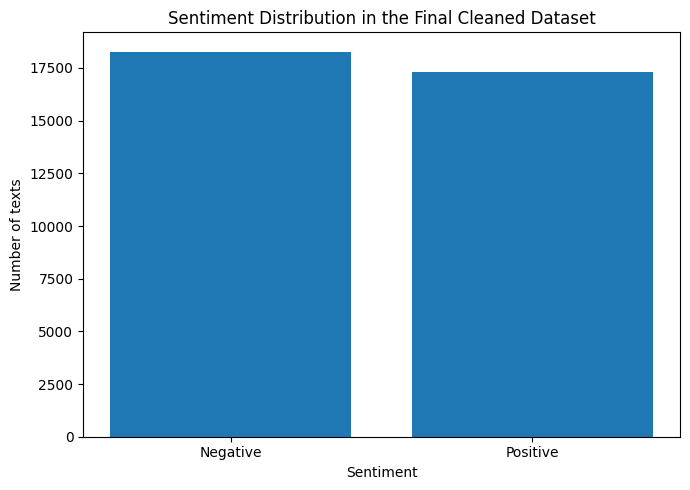

Majority-to-minority ratio: 1.055


In [14]:
class_counts = clean_combined_df[LABEL_COLUMN].value_counts().reindex(["neg", "pos"], fill_value=0)
class_summary = pd.DataFrame({
    "Sentiment": ["Negative", "Positive"],
    "Count": [class_counts["neg"], class_counts["pos"]],
    "Percentage": [
        class_counts["neg"] / len(clean_combined_df) * 100,
        class_counts["pos"] / len(clean_combined_df) * 100
    ]
})
display(class_summary.round(3))

plt.figure(figsize=(7, 5))
plt.bar(class_summary["Sentiment"], class_summary["Count"])
plt.xlabel("Sentiment")
plt.ylabel("Number of texts")
plt.title("Sentiment Distribution in the Final Cleaned Dataset")
plt.tight_layout()
plt.show()

print("Majority-to-minority ratio:", round(class_counts.max() / class_counts.min(), 4))

# Compare Text Length Across Sentiment Classes

character_count                                 word_count         \
                count   mean median     std min   max      count   mean   
label                                                                     
neg             18277  53.74   41.0   94.80   5  5821      18277  11.03   
pos             17324  65.82   54.0  146.69   6  7962      17324  13.27   

                               
      median    std min   max  
label                          
neg      9.0  19.03   3  1177  
pos     11.0  29.10   3  1554

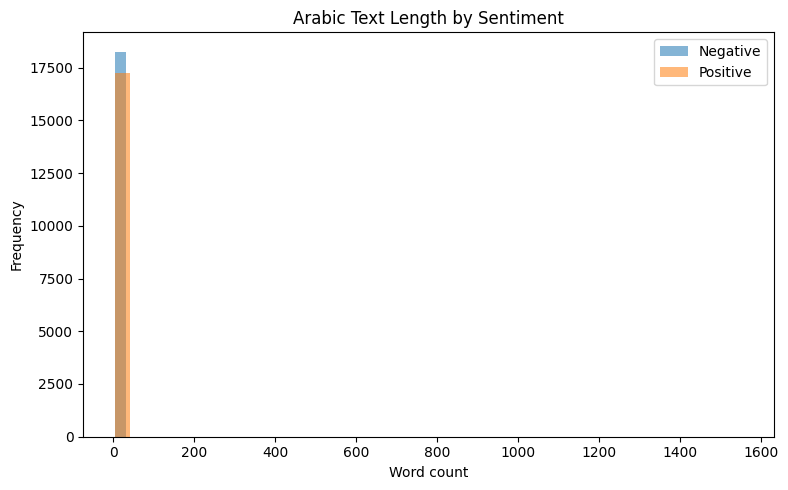

In [15]:
display(
    eda_df.groupby(LABEL_COLUMN)[["character_count", "word_count"]]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .round(2)
)

plt.figure(figsize=(8, 5))
for label, label_name in [("neg", "Negative"), ("pos", "Positive")]:
    values = eda_df.loc[eda_df[LABEL_COLUMN] == label, "word_count"]
    plt.hist(values, bins=40, alpha=0.55, label=label_name)
plt.xlabel("Word count")
plt.ylabel("Frequency")
plt.title("Arabic Text Length by Sentiment")
plt.legend()
plt.tight_layout()
plt.show()

# Inspect Shortest and Longest Cleaned Texts

In [16]:
print("Five shortest texts:")
display(eda_df.sort_values("word_count")[["clean_text", LABEL_COLUMN, "word_count"]].head(5))

print("\nFive longest texts:")
display(eda_df.sort_values("word_count", ascending=False)[["clean_text", LABEL_COLUMN, "word_count"]].head(5))

Five shortest texts:


,clean_text,label,word_count
22633,شكرا اووي 😍,pos,3
16096,لبيك يا علي,pos,3
94,حرفيا يمثلني 💔,neg,3
16042,الف سلامه 🌹,pos,3
16052,مااعرف انامم :),pos,3



Five longest texts:


,clean_text,label,word_count
28705,اللهم عليك متوكلين وبك نظن الظن الجميل، يارب قدرا جميلا وخيرا يتبعه الرضا، ربي نعتمد عليك وبك نستعين، رب ارز… pos حبي والي بيحبك كل يوم بيمدحك وكل دقيقه 😉 p...,pos,1554
23228,،• ان الغروب لا يحول دون شروق جديد..🌥 سيغرب حزنك.. و ستشرق فرحتك.. ثق بالله .. ابتسم و لا تشغل نفسك… pos اذكر الله يذكرك - سبحان الله - الحمدلله - الله اكبر...,pos,1354
18402,اللهم في بداية هذا الصباح 🌤 اسالك ايام حلوة 🌿 تورد الحياة بداخلنا ، 🍀 ك دعاء يستجاب او امنية تتحقق 🕊 pos طيب الاغاني الحلوه راحت علينا 😂 pos وش_يقول_الليل م...,pos,1302
28310,وصوتها امان .. يحضن قلبي قبل مسمعي 💛 pos 4.19 || 🥰 انا وحدي سهرانة، باقي الادمنز متعبات جدا 🥺❤️ اتمني ان يحظوا بنوم هادئ ومريح 💜 ماذا عنكم ارميز؟؟ هل… pos و...,pos,1198
2630,الان قد كسرت! وانا الذي ظللت متماسكا لفتره طويله جدا.. ها قد فقدت كل دافع كان يحفزني للوصول اليك.. فقد انتظر… neg ﺳﺘﻌﻠﻤﻚ ﺍﻟﺤﻴﺂﺓ ﺃﻥ ﺃﻛﺒﺮ ﺧﻄﺄ ﻳﺼﺪﺭ ﻣﻨﺂ ﺃﻥ ﻧﻜﻮﻥ...,neg,1177


# Create Stratified Train-Validation-Test Splits

The final cleaned corpus is divided into 70% training, 15% validation, and 15% test data. The new test set is an internal hold-out reconstructed from the combined corpus; the publisher's original test split is not retained because the original splits contained overlapping and conflicting texts.

In [17]:
X_full = clean_combined_df["clean_text"].reset_index(drop=True)
y_full = clean_combined_df["label_binary"].reset_index(drop=True)

X_train, X_temp, y_train, y_temp = train_test_split(
    X_full, y_full, test_size=0.30, random_state=RANDOM_STATE, stratify=y_full
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=RANDOM_STATE, stratify=y_temp
)

X_train = X_train.reset_index(drop=True)
X_val = X_val.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
y_val = y_val.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

print("Training observations   :", len(X_train))
print("Validation observations :", len(X_val))
print("Test observations       :", len(X_test))
print("Total partitioned rows  :", len(X_train) + len(X_val) + len(X_test))

Training observations   : 24920
Validation observations : 5340
Test observations       : 5341
Total partitioned rows  : 35601


# Verify That Cleaned Texts Do Not Overlap Across Splits

The final partitions must have zero exact overlap in normalized text. Assertions stop the notebook if any overlap remains.

In [18]:
train_text_set = set(X_train)
val_text_set = set(X_val)
test_text_set = set(X_test)

train_val_overlap = len(train_text_set.intersection(val_text_set))
train_test_overlap = len(train_text_set.intersection(test_text_set))
val_test_overlap = len(val_text_set.intersection(test_text_set))

print("Train-Validation overlap:", train_val_overlap)
print("Train-Test overlap      :", train_test_overlap)
print("Validation-Test overlap :", val_test_overlap)

assert train_val_overlap == 0, "Train-validation overlap detected."
assert train_test_overlap == 0, "Train-test overlap detected."
assert val_test_overlap == 0, "Validation-test overlap detected."
print("Leakage check passed: no exact cleaned texts are shared across splits.")

Train-Validation overlap: 0
Train-Test overlap      : 0
Validation-Test overlap : 0
Leakage check passed: no exact cleaned texts are shared across splits.


# Examine Class Proportions in Each Split

This table confirms that stratification preserves similar sentiment proportions across training, validation, and test subsets.

In [19]:
split_rows = []
for split_name, labels in [("Train", y_train), ("Validation", y_val), ("Test", y_test)]:
    counts = labels.value_counts().reindex([0, 1], fill_value=0)
    split_rows.append({
        "Split": split_name,
        "Rows": len(labels),
        "Negative Count": int(counts[0]),
        "Negative %": counts[0] / len(labels) * 100,
        "Positive Count": int(counts[1]),
        "Positive %": counts[1] / len(labels) * 100
    })

split_summary = pd.DataFrame(split_rows)
display(split_summary.round(3))

train_class_counts = y_train.value_counts().sort_index()
imbalance_ratio = train_class_counts.max() / train_class_counts.min()
print("Training class counts (0=Negative, 1=Positive):")
print(train_class_counts)
print("Training majority-to-minority ratio:", round(imbalance_ratio, 4))
print("Class weighting: not enabled for the baseline; the class distribution is inspected first.")

,Split,Rows,Negative Count,Negative %,Positive Count,Positive %
0,Train,24920,12794,51.340,12126,48.660
1,Validation,5340,2741,51.330,2599,48.670
2,Test,5341,2742,51.339,2599,48.661


Training class counts (0=Negative, 1=Positive):
label_binary
0    12794
1    12126
Name: count, dtype: int64
Training majority-to-minority ratio: 1.0551
Class weighting: not enabled for the baseline; the class distribution is inspected first.


## Result Interpretation — Arabic-Specific Text Diagnostics

Alef variants were found in **23,180 texts (40.81%)**, while hashtag markers appeared in **9,692 texts (17.07%)**. Zero-width characters were detected in 510 texts (0.90%). No URLs, user mentions, or Tatweel were detected by the applied patterns. These findings support normalizing common Arabic character variations while preserving hashtag content and sentiment-related information.

## Result Interpretation — Final Dataset and Text Lengths

The final dataset contained **35,601 unique Arabic texts**. The average text length was **59.62 characters and 12.12 words**, compared with medians of 47 characters and 10 words. The maximum length reached 7,962 characters, indicating a right-skewed distribution with a small number of unusually long texts.

## Result Interpretation — Sentiment Class Balance

The dataset contained **18,277 negative texts (51.34%)** and **17,324 positive texts (48.66%)**. The majority-to-minority ratio was **1.0551**, indicating a highly balanced class distribution. Therefore, substantial corrective class weighting was not indicated by the observed proportions.

## Result Interpretation — Text Length by Sentiment

Positive texts were slightly longer on average, with **13.27 words** compared with **11.03 words** for negative texts. Their median lengths were 11 and 9 words, respectively. Both groups included unusually long texts, so the differences describe the dataset rather than establish a relationship between length and sentiment.

## Result Interpretation — Shortest and Longest Texts

The shortest cleaned texts contained **three words**, while the longest contained up to **1,554 words**. Short examples showed that sentiment can be expressed through brief Arabic phrases and emojis. Long texts were retained because length alone does not indicate invalid data, although truncation may affect their processing by MARBERT.

## Result Interpretation — Final Data Split

Stratified sampling produced **24,920 training observations, 5,340 validation observations, and 5,341 test observations**. Class proportions remained consistent across the three subsets, with approximately 51.3% negative and 48.7% positive texts.

The overlap checks returned **zero shared texts** between all pairs of subsets. The reconstructed test set is therefore reserved for final evaluation without exact cleaned-text overlap with training or validation data.

# Classical NLP: Build the TF-IDF Representation

TF-IDF converts the Arabic texts into numerical vectors using word unigrams and bigrams. The vectorizer is fitted only on training text; validation and test data are transformed with that fitted vocabulary to prevent leakage.

In [20]:
tfidf_vectorizer = TfidfVectorizer(
    lowercase=False,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.98,
    sublinear_tf=True
)

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_val_tfidf = tfidf_vectorizer.transform(X_val)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print("Training TF-IDF shape  :", X_train_tfidf.shape)
print("Validation TF-IDF shape:", X_val_tfidf.shape)
print("Test TF-IDF shape      :", X_test_tfidf.shape)
print("Vocabulary size        :", len(tfidf_vectorizer.vocabulary_))

Training TF-IDF shape  : (24920, 40261)
Validation TF-IDF shape: (5340, 40261)
Test TF-IDF shape      : (5341, 40261)
Vocabulary size        : 40261


# Train the Logistic Regression Baseline

Logistic Regression provides a classical baseline and offers directly interpretable feature coefficients. Balanced class weights are not enabled by default; the final class distribution is already assessed in the preceding section.

In [21]:
tfidf_model = LogisticRegression(
    max_iter=2000,
    class_weight=None,
    random_state=RANDOM_STATE
)

tfidf_start = time.perf_counter()
tfidf_model.fit(X_train_tfidf, y_train)
tfidf_training_time = time.perf_counter() - tfidf_start

print("TF-IDF + Logistic Regression training completed.")
print(f"Training time: {tfidf_training_time:.2f} seconds")

TF-IDF + Logistic Regression training completed.
Training time: 1.86 seconds


# Evaluate TF-IDF on the Validation Set

Validation results provide the classical baseline for comparison with MARBERT.

In [22]:
tfidf_val_pred = tfidf_model.predict(X_val_tfidf)
tfidf_val_prob = tfidf_model.predict_proba(X_val_tfidf)[:, 1]

tfidf_val_metrics = classification_metrics(
    y_val, tfidf_val_pred, tfidf_val_prob
)

print("TF-IDF + Logistic Regression — Validation Results")
display(pd.DataFrame([tfidf_val_metrics], index=["TF-IDF + Logistic Regression"]).round(4))

TF-IDF + Logistic Regression — Validation Results


,Accuracy,Precision,Recall,F1,ROC-AUC,Average Precision,Balanced Accuracy
TF-IDF + Logistic Regression,0.674,0.6864,0.6079,0.6448,0.7378,0.7363,0.6723


# Inspect TF-IDF Validation Errors

The confusion matrix and classification report show the error balance between negative and positive sentiment.

              precision    recall  f1-score   support

    Negative     0.6646    0.7366    0.6987      2741
    Positive     0.6864    0.6079    0.6448      2599

    accuracy                         0.6740      5340
   macro avg     0.6755    0.6723    0.6718      5340
weighted avg     0.6752    0.6740    0.6725      5340



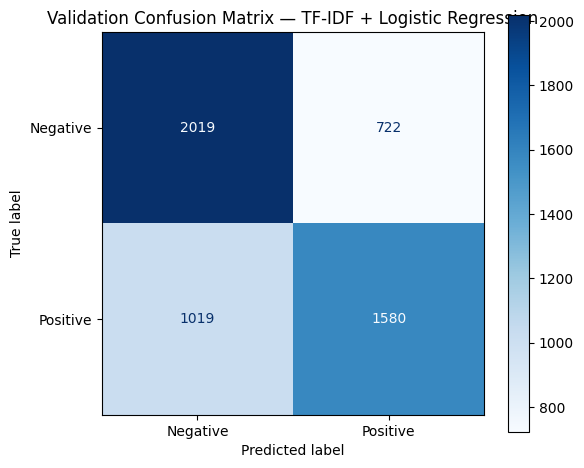

In [23]:
print(classification_report(
    y_val, tfidf_val_pred,
    labels=[0, 1],
    target_names=["Negative", "Positive"],
    digits=4,
    zero_division=0
))

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_val, tfidf_val_pred,
    labels=[0, 1],
    display_labels=["Negative", "Positive"],
    cmap="Blues", ax=ax
)
ax.set_title("Validation Confusion Matrix — TF-IDF + Logistic Regression")
plt.tight_layout()
plt.show()

# Interpret the Most Important TF-IDF Features

Logistic Regression coefficients show terms and n-grams associated with each sentiment class. Positive coefficients point toward positive predictions and negative coefficients point toward negative predictions. They represent model associations, not causal linguistic effects.

In [24]:
tfidf_features = np.array(tfidf_vectorizer.get_feature_names_out())
tfidf_coefficients = tfidf_model.coef_[0]

top_positive_indices = np.argsort(tfidf_coefficients)[-25:][::-1]
top_negative_indices = np.argsort(tfidf_coefficients)[:25]

top_positive_features = pd.DataFrame({
    "Feature": tfidf_features[top_positive_indices],
    "Coefficient": tfidf_coefficients[top_positive_indices]
})
top_negative_features = pd.DataFrame({
    "Feature": tfidf_features[top_negative_indices],
    "Coefficient": tfidf_coefficients[top_negative_indices]
})

print("Features most associated with positive predictions:")
display(top_positive_features.round(4))
print("\nFeatures most associated with negative predictions:")
display(top_negative_features.round(4))

Features most associated with positive predictions:


,Feature,Coefficient
0,اللهم,3.7264
1,صباحك,2.8354
2,الطيب,2.7747
3,صباح,2.5744
4,الصباح,2.4753
5,جميلة,2.4642
6,الحمدلله,2.2858
7,يسعدك,2.2574
8,محمد,2.2208
9,صباحكم,2.1000



Features most associated with negative predictions:


,Feature,Coefficient
0,مسلسل_ودك_يتكرر_برمضان,-3.1513
1,ليش,-2.5323
2,يمه,-2.1238
3,احس,-2.0442
4,مو,-2.0310
5,اشتقت,-2.0177
6,اجازة,-1.8571
7,للاسف,-1.8352
8,تو,-1.7754
9,بسبب,-1.7036


# Load the MARBERT Tokenizer

The Transformer approach uses `UBC-NLP/MARBERT`, a pretrained Arabic language model designed for Modern Standard Arabic and dialectal Arabic. Its contextual token representations differ from TF-IDF's word and n-gram weights.

In [25]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print("Tokenizer loaded successfully.")
print("Model:", MODEL_NAME)
print("Vocabulary size:", tokenizer.vocab_size)
print("Maximum sequence length:", MAX_LENGTH)

config.json:   0%|          | 0.00/701 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/376 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/1.10M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Tokenizer loaded successfully.
Model: UBC-NLP/MARBERT
Vocabulary size: 100000
Maximum sequence length: 128


# Prepare Hugging Face Datasets

The exact same cleaned texts and labels used for the TF-IDF model are prepared for MARBERT.

In [26]:
train_hf = pd.DataFrame({"text": X_train, "label": y_train.astype(int)})
val_hf = pd.DataFrame({"text": X_val, "label": y_val.astype(int)})
test_hf = pd.DataFrame({"text": X_test, "label": y_test.astype(int)})

train_dataset = Dataset.from_pandas(train_hf, preserve_index=False)
val_dataset = Dataset.from_pandas(val_hf, preserve_index=False)
test_dataset = Dataset.from_pandas(test_hf, preserve_index=False)

print("Training dataset:", train_dataset)
print("Validation dataset:", val_dataset)
print("Test dataset:", test_dataset)

Training dataset: Dataset({
    features: ['text', 'label'],
    num_rows: 24920
})
Validation dataset: Dataset({
    features: ['text', 'label'],
    num_rows: 5340
})
Test dataset: Dataset({
    features: ['text', 'label'],
    num_rows: 5341
})


# Tokenize Arabic Text for MARBERT

Text is converted to token IDs and attention masks. Text longer than `MAX_LENGTH` is truncated, while batch padding is applied dynamically later.

In [27]:
def tokenize_batch(batch):
    return tokenizer(batch["text"], truncation=True, max_length=MAX_LENGTH)

train_tokenized = train_dataset.map(
    tokenize_batch, batched=True, remove_columns=["text"]
)
val_tokenized = val_dataset.map(
    tokenize_batch, batched=True, remove_columns=["text"]
)
test_tokenized = test_dataset.map(
    tokenize_batch, batched=True, remove_columns=["text"]
)

print("Tokenization completed.")
print("Training:", train_tokenized)
print("Validation:", val_tokenized)
print("Test:", test_tokenized)

Map:   0%|          | 0/24920 [00:00<?, ? examples/s]

Map:   0%|          | 0/5340 [00:00<?, ? examples/s]

Map:   0%|          | 0/5341 [00:00<?, ? examples/s]

Tokenization completed.
Training: Dataset({
    features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 24920
})
Validation: Dataset({
    features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 5340
})
Test: Dataset({
    features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 5341
})


# Initialize MARBERT for Binary Classification

The classification head maps the text into two sentiment labels: `0 = Negative` and `1 = Positive`.

In [28]:
id2label = {0: "Negative", 1: "Positive"}
label2id = {"Negative": 0, "Positive": 1}

marbert_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
    id2label=id2label,
    label2id=label2id
)

print("MARBERT classification model initialized.")

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  654MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

model.safetensors: reconstructing file:   0%|          |  0.00B /  654MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: UBC-NLP/MARBERT
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider

MARBERT classification model initialized.


# Define Common Metrics for MARBERT

The Transformer is evaluated with the same metrics as the classical baseline, including ROC-AUC and Average Precision based on positive-class probabilities.

In [29]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    logits = np.asarray(logits)
    labels = np.asarray(labels)
    positive_probability = softmax(logits, axis=1)[:, 1]
    predictions = np.argmax(logits, axis=1)

    metrics = classification_metrics(labels, predictions, positive_probability)
    # Trainer expects lowercase metric keys so eval_f1 is available for checkpoint selection.
    return {key.lower().replace(" ", "_"): value for key, value in metrics.items()}

# Configure MARBERT Fine-Tuning

The model is fine-tuned for a limited, documented number of epochs. The validation set is evaluated at each epoch, and the best checkpoint is selected by validation F1-score. A GPU runtime is recommended.

In [30]:
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

training_args_kwargs = {
    "output_dir": "./marbert_arabic_sentiment",
    "save_strategy": "epoch",
    "learning_rate": 2e-5,
    "per_device_train_batch_size": 16 if torch.cuda.is_available() else 8,
    "per_device_eval_batch_size": 32 if torch.cuda.is_available() else 8,
    "num_train_epochs": NUM_TRAIN_EPOCHS,
    "weight_decay": 0.01,
    "load_best_model_at_end": True,
    "metric_for_best_model": "f1",
    "greater_is_better": True,
    "logging_strategy": "epoch",
    "save_total_limit": 2,
    "report_to": "none",
    "fp16": torch.cuda.is_available(),
    "seed": RANDOM_STATE
}

# Support Transformers versions with either evaluation argument name.
training_args_signature = inspect.signature(TrainingArguments.__init__).parameters
if "eval_strategy" in training_args_signature:
    training_args_kwargs["eval_strategy"] = "epoch"
else:
    training_args_kwargs["evaluation_strategy"] = "epoch"

training_args = TrainingArguments(**training_args_kwargs)

trainer_kwargs = {
    "model": marbert_model,
    "args": training_args,
    "train_dataset": train_tokenized,
    "eval_dataset": val_tokenized,
    "data_collator": data_collator,
    "compute_metrics": compute_metrics
}

trainer_signature = inspect.signature(Trainer.__init__).parameters
if "processing_class" in trainer_signature:
    trainer_kwargs["processing_class"] = tokenizer
else:
    trainer_kwargs["tokenizer"] = tokenizer

trainer = Trainer(**trainer_kwargs)

print("MARBERT Trainer configured.")
print("Epochs:", NUM_TRAIN_EPOCHS)
print("Training batch size:", training_args.per_device_train_batch_size)
print("Evaluation batch size:", training_args.per_device_eval_batch_size)

MARBERT Trainer configured.
Epochs: 2
Training batch size: 16
Evaluation batch size: 32


# Fine-Tune MARBERT

The test set is not passed to the Trainer and is therefore not used to update model parameters or select the checkpoint.

In [31]:
marbert_training_start = time.perf_counter()
train_output = trainer.train()
marbert_training_time = time.perf_counter() - marbert_training_start

print("MARBERT fine-tuning completed.")
print(f"Training time: {marbert_training_time / 60:.2f} minutes")

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Roc-auc,Average Precision,Balanced Accuracy
1,0.210351,0.172282,0.934270,0.918466,0.949211,0.933586,0.984666,0.983549,0.934657
2,0.137621,0.217363,0.935955,0.940304,0.927280,0.933747,0.985359,0.984589,0.935730


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

MARBERT fine-tuning completed.
Training time: 6.30 minutes


# Inspect Training Loss and Validation History

The training log is examined to understand the training trajectory and validation F1-score across epochs.

,loss,grad_norm,learning_rate,epoch,step,eval_loss,eval_accuracy,eval_precision,eval_recall,eval_f1,eval_roc-auc,eval_average_precision,eval_balanced_accuracy,eval_runtime,eval_samples_per_second,eval_steps_per_second,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss
0,0.2104,1.9571,0.0,1.0,1558,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,1.0,1558,0.1723,0.9343,0.9185,0.9492,0.9336,0.9847,0.9835,0.9347,3.7000,1443.237,45.135,NaN,NaN,NaN,NaN,NaN
2,0.1376,3.7646,0.0,2.0,3116,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,2.0,3116,0.2174,0.9360,0.9403,0.9273,0.9337,0.9854,0.9846,0.9357,3.8212,1397.465,43.704,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,2.0,3116,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,375.7604,132.638,8.293,8.976979e+14,0.174


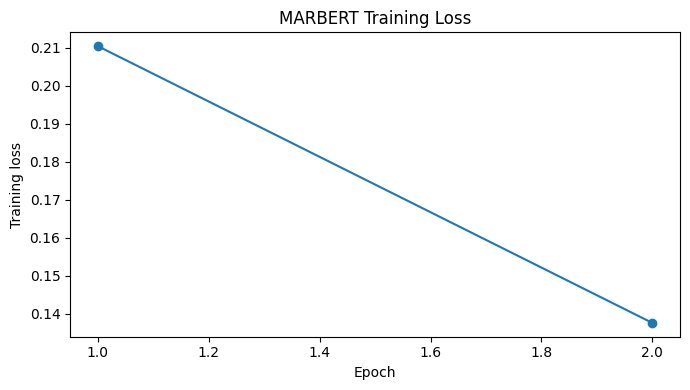

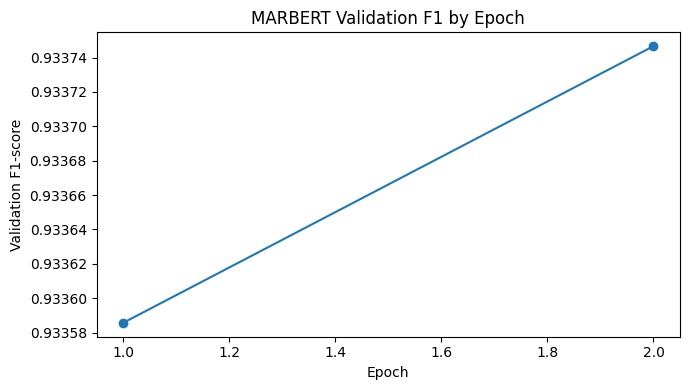

In [32]:
training_log_df = pd.DataFrame(trainer.state.log_history)
display(training_log_df.round(4))

if "loss" in training_log_df.columns:
    loss_rows = training_log_df[training_log_df["loss"].notna()]
    if len(loss_rows):
        plt.figure(figsize=(7, 4))
        plt.plot(loss_rows["epoch"], loss_rows["loss"], marker="o")
        plt.xlabel("Epoch")
        plt.ylabel("Training loss")
        plt.title("MARBERT Training Loss")
        plt.tight_layout()
        plt.show()

if "eval_f1" in training_log_df.columns:
    eval_rows = training_log_df[training_log_df["eval_f1"].notna()]
    if len(eval_rows):
        plt.figure(figsize=(7, 4))
        plt.plot(eval_rows["epoch"], eval_rows["eval_f1"], marker="o")
        plt.xlabel("Epoch")
        plt.ylabel("Validation F1-score")
        plt.title("MARBERT Validation F1 by Epoch")
        plt.tight_layout()
        plt.show()

# Evaluate MARBERT on the Validation Set

Validation predictions are used to compare MARBERT with the TF-IDF baseline before the final test evaluation.

In [33]:
marbert_val_output = trainer.predict(val_tokenized)
marbert_val_logits = np.asarray(marbert_val_output.predictions)
marbert_val_pred = np.argmax(marbert_val_logits, axis=1)
marbert_val_prob = softmax(marbert_val_logits, axis=1)[:, 1]

marbert_val_metrics = classification_metrics(
    y_val, marbert_val_pred, marbert_val_prob
)

print("MARBERT — Validation Results")
display(pd.DataFrame([marbert_val_metrics], index=["MARBERT"]).round(4))

MARBERT — Validation Results


,Accuracy,Precision,Recall,F1,ROC-AUC,Average Precision,Balanced Accuracy
MARBERT,0.936,0.9403,0.9273,0.9337,0.9854,0.9846,0.9357


# Compare Validation Performance

Both approaches are evaluated on the same validation texts with the same metrics.

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,Average Precision,Balanced Accuracy
0,MARBERT,0.936,0.9403,0.9273,0.9337,0.9854,0.9846,0.9357
1,TF-IDF + Logistic Regression,0.674,0.6864,0.6079,0.6448,0.7378,0.7363,0.6723


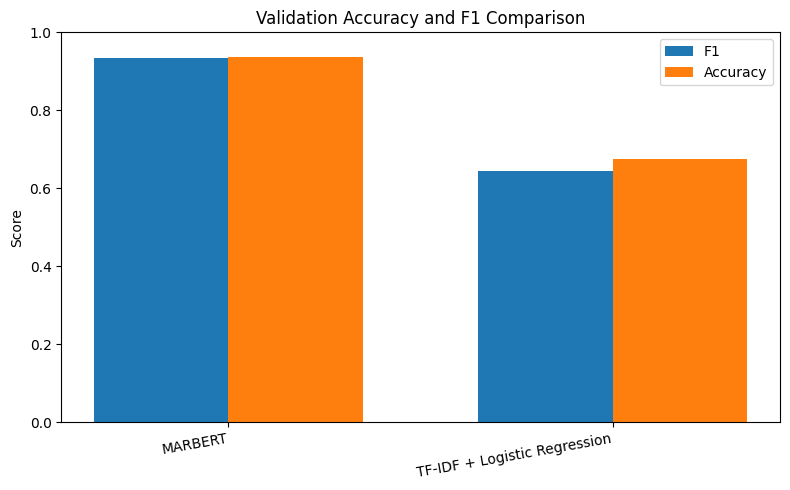

In [34]:
validation_results = pd.DataFrame([
    {"Model": "TF-IDF + Logistic Regression", **tfidf_val_metrics},
    {"Model": "MARBERT", **marbert_val_metrics}
]).sort_values("F1", ascending=False).reset_index(drop=True)

display(validation_results.round(4))

plt.figure(figsize=(8, 5))
x = np.arange(len(validation_results))
width = 0.35
plt.bar(x - width / 2, validation_results["F1"], width, label="F1")
plt.bar(x + width / 2, validation_results["Accuracy"], width, label="Accuracy")
plt.xticks(x, validation_results["Model"], rotation=10, ha="right")
plt.ylim(0, 1)
plt.ylabel("Score")
plt.title("Validation Accuracy and F1 Comparison")
plt.legend()
plt.tight_layout()
plt.show()

# Examine Validation Confusion Matrices and Class-Wise Scores

These diagnostic results help establish which error types differ before we proceed to the test set.

TF-IDF + Logistic Regression
              precision    recall  f1-score   support

    Negative     0.6646    0.7366    0.6987      2741
    Positive     0.6864    0.6079    0.6448      2599

    accuracy                         0.6740      5340
   macro avg     0.6755    0.6723    0.6718      5340
weighted avg     0.6752    0.6740    0.6725      5340



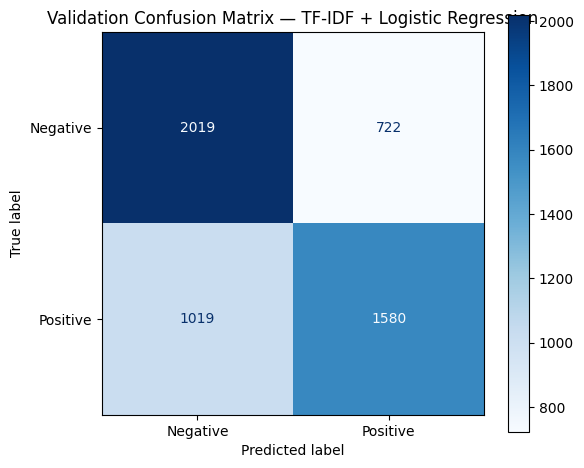

MARBERT
              precision    recall  f1-score   support

    Negative     0.9319    0.9442    0.9380      2741
    Positive     0.9403    0.9273    0.9337      2599

    accuracy                         0.9360      5340
   macro avg     0.9361    0.9357    0.9359      5340
weighted avg     0.9360    0.9360    0.9359      5340



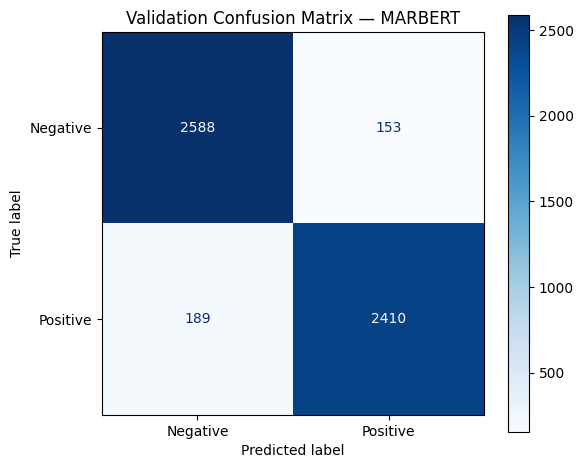

In [35]:
validation_predictions = {
    "TF-IDF + Logistic Regression": tfidf_val_pred,
    "MARBERT": marbert_val_pred
}

for model_name, predictions in validation_predictions.items():
    print("=" * 80)
    print(model_name)
    print(classification_report(
        y_val, predictions,
        labels=[0, 1],
        target_names=["Negative", "Positive"],
        digits=4,
        zero_division=0
    ))

    fig, ax = plt.subplots(figsize=(6, 5))
    ConfusionMatrixDisplay.from_predictions(
        y_val, predictions,
        labels=[0, 1],
        display_labels=["Negative", "Positive"],
        cmap="Blues",
        ax=ax
    )
    ax.set_title(f"Validation Confusion Matrix — {model_name}")
    plt.tight_layout()
    plt.show()

# Select the Candidate Model Using Validation F1

This cell documents the candidate model selected from the validation results. Test-set results are not used for this decision.

In [36]:
best_model_name = validation_results.loc[
    validation_results["F1"].idxmax(), "Model"
]
print("Model selected by validation F1:", best_model_name)

Model selected by validation F1: MARBERT


# Evaluate Both Models on the Held-Out Test Set

The final test partition has not been used for fitting or validation-based model selection. Predictions are generated once for each model and reused in subsequent reporting cells.

In [37]:
tfidf_test_pred = tfidf_model.predict(X_test_tfidf)
tfidf_test_prob = tfidf_model.predict_proba(X_test_tfidf)[:, 1]
tfidf_test_metrics = classification_metrics(
    y_test, tfidf_test_pred, tfidf_test_prob
)

marbert_test_output = trainer.predict(test_tokenized)
marbert_test_logits = np.asarray(marbert_test_output.predictions)
marbert_test_pred = np.argmax(marbert_test_logits, axis=1)
marbert_test_prob = softmax(marbert_test_logits, axis=1)[:, 1]
marbert_test_metrics = classification_metrics(
    y_test, marbert_test_pred, marbert_test_prob
)

final_results = pd.DataFrame([
    {"Model": "TF-IDF + Logistic Regression", **tfidf_test_metrics},
    {"Model": "MARBERT", **marbert_test_metrics}
]).sort_values("F1", ascending=False).reset_index(drop=True)

print("Final held-out test performance:")
display(final_results.round(4))

Final held-out test performance:


,Model,Accuracy,Precision,Recall,F1,ROC-AUC,Average Precision,Balanced Accuracy
0,MARBERT,0.9397,0.9484,0.9265,0.9373,0.9870,0.9863,0.9394
1,TF-IDF + Logistic Regression,0.6703,0.6846,0.5979,0.6383,0.7235,0.7244,0.6684


# Plot the Main Test Metrics

Separate charts make it easier to compare the two approaches across the main predictive metrics. The numerical table above remains the source for exact values.

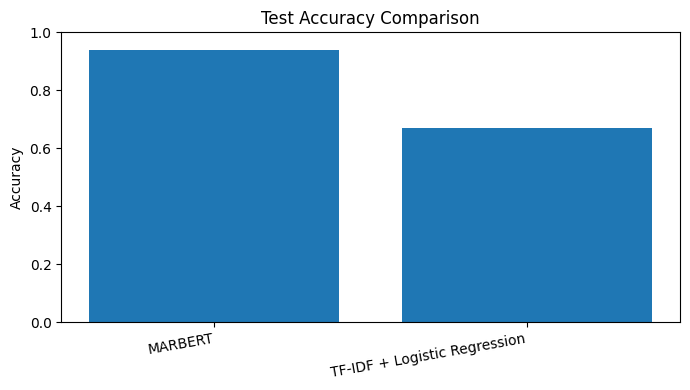

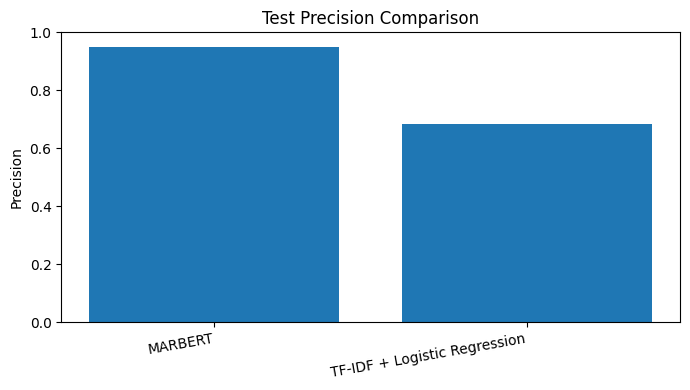

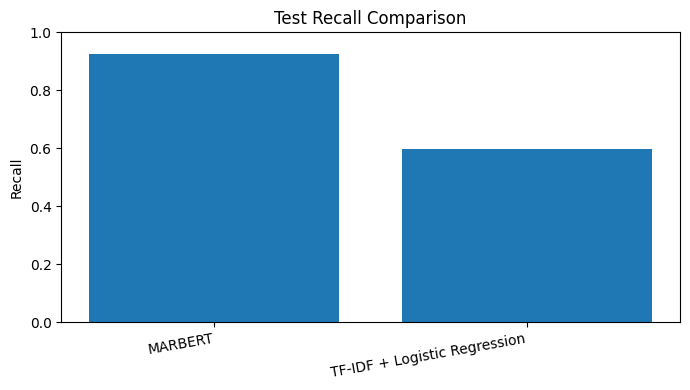

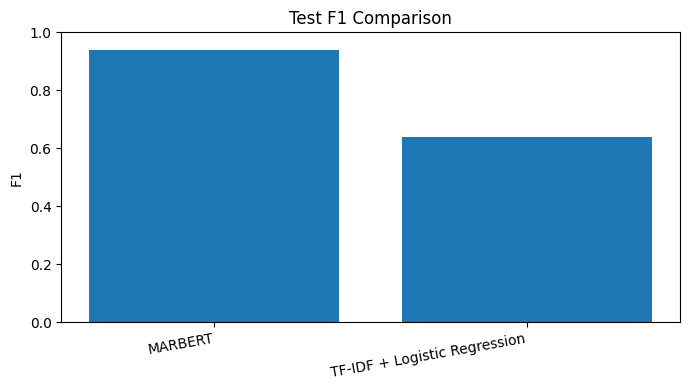

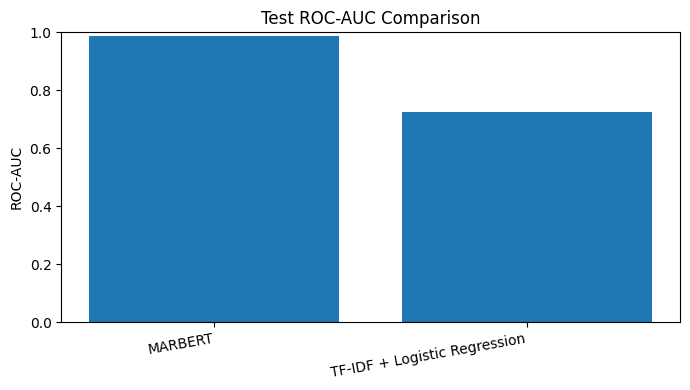

In [38]:
for metric in ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]:
    plt.figure(figsize=(7, 4))
    plt.bar(final_results["Model"], final_results[metric])
    plt.ylim(0, 1)
    plt.ylabel(metric)
    plt.title(f"Test {metric} Comparison")
    plt.xticks(rotation=10, ha="right")
    plt.tight_layout()
    plt.show()

# Test Confusion Matrices and Classification Reports

Confusion matrices distinguish false positives from false negatives. The classification reports show how each model performs on negative and positive sentiment separately.

TF-IDF + Logistic Regression
              precision    recall  f1-score   support

    Negative     0.6597    0.7389    0.6971      2742
    Positive     0.6846    0.5979    0.6383      2599

    accuracy                         0.6703      5341
   macro avg     0.6722    0.6684    0.6677      5341
weighted avg     0.6718    0.6703    0.6685      5341



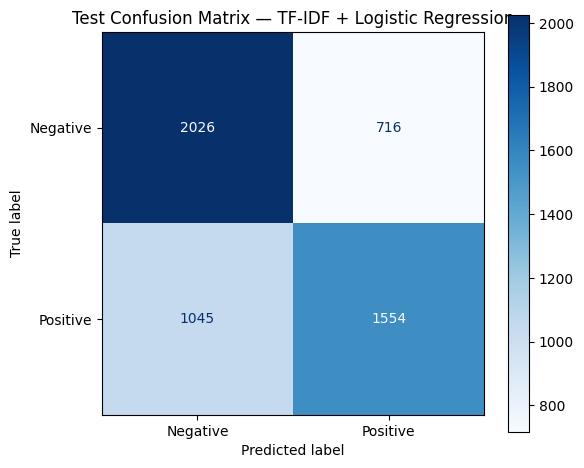

MARBERT
              precision    recall  f1-score   support

    Negative     0.9318    0.9522    0.9419      2742
    Positive     0.9484    0.9265    0.9373      2599

    accuracy                         0.9397      5341
   macro avg     0.9401    0.9394    0.9396      5341
weighted avg     0.9399    0.9397    0.9397      5341



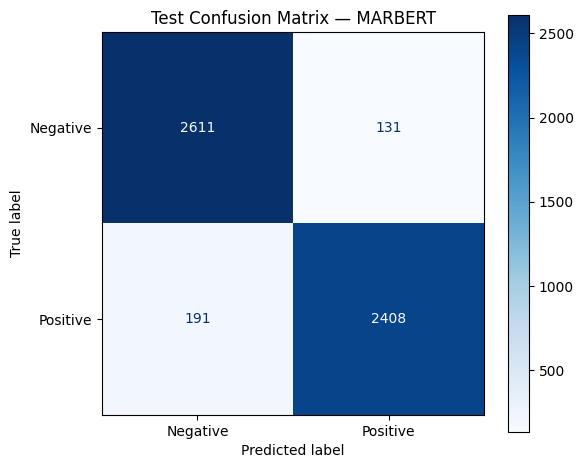

In [39]:
test_predictions = {
    "TF-IDF + Logistic Regression": tfidf_test_pred,
    "MARBERT": marbert_test_pred
}

for model_name, predictions in test_predictions.items():
    print("=" * 80)
    print(model_name)
    print(classification_report(
        y_test, predictions,
        labels=[0, 1],
        target_names=["Negative", "Positive"],
        digits=4,
        zero_division=0
    ))

    fig, ax = plt.subplots(figsize=(6, 5))
    ConfusionMatrixDisplay.from_predictions(
        y_test, predictions,
        labels=[0, 1],
        display_labels=["Negative", "Positive"],
        cmap="Blues",
        ax=ax
    )
    ax.set_title(f"Test Confusion Matrix — {model_name}")
    plt.tight_layout()
    plt.show()

# Compare ROC and Precision-Recall Curves

ROC-AUC measures discrimination across thresholds, while Average Precision summarizes the precision-recall curve. These complement the threshold-specific confusion matrices and F1-score.

<Figure size 700x500 with 0 Axes>

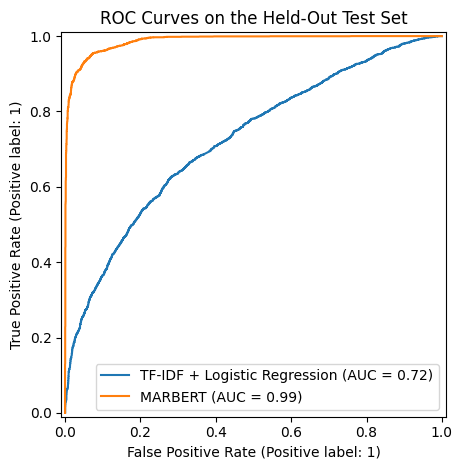

<Figure size 700x500 with 0 Axes>

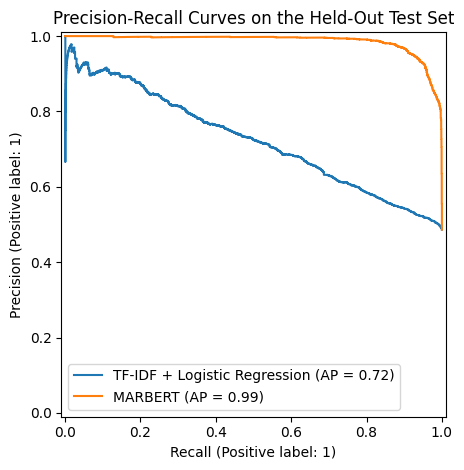

In [40]:
plt.figure(figsize=(7, 5))
RocCurveDisplay.from_predictions(
    y_test, tfidf_test_prob, name="TF-IDF + Logistic Regression"
)
RocCurveDisplay.from_predictions(
    y_test, marbert_test_prob, name="MARBERT", ax=plt.gca()
)
plt.title("ROC Curves on the Held-Out Test Set")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 5))
PrecisionRecallDisplay.from_predictions(
    y_test, tfidf_test_prob, name="TF-IDF + Logistic Regression"
)
PrecisionRecallDisplay.from_predictions(
    y_test, marbert_test_prob, name="MARBERT", ax=plt.gca()
)
plt.title("Precision-Recall Curves on the Held-Out Test Set")
plt.tight_layout()
plt.show()

# Paired Bootstrap Confidence Interval for Test F1 Difference

This analysis estimates uncertainty in the F1 difference between MARBERT and TF-IDF by resampling the same test observations for both models. The reported interval is an approximate 95% percentile confidence interval for `MARBERT F1 − TF-IDF F1`; it is not evidence about every Arabic domain.

,F1 Difference (MARBERT - TF-IDF),95% CI Lower,95% CI Upper,Bootstrap Replications,CI Includes Zero
0,0.29901,0.28378,0.31552,1000,False


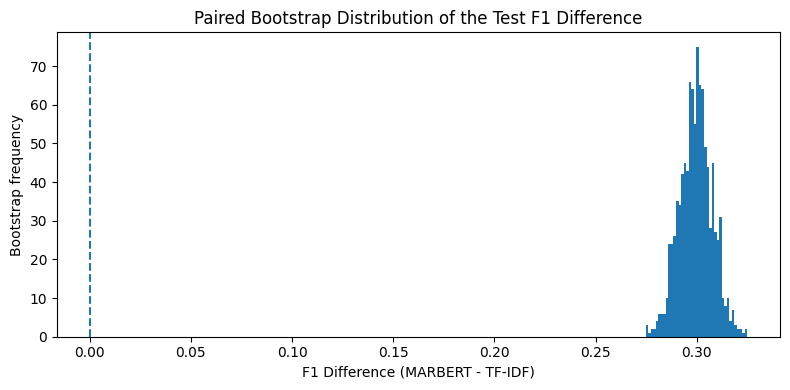

In [41]:
def paired_bootstrap_f1_difference(
    y_true, pred_a, pred_b,
    n_bootstrap=1000,
    random_state=RANDOM_STATE
):
    y_true = np.asarray(y_true)
    pred_a = np.asarray(pred_a)
    pred_b = np.asarray(pred_b)
    rng = np.random.default_rng(random_state)
    n = len(y_true)
    differences = np.empty(n_bootstrap, dtype=float)

    for b in range(n_bootstrap):
        indices = rng.integers(0, n, size=n)
        f1_a = f1_score(y_true[indices], pred_a[indices], zero_division=0)
        f1_b = f1_score(y_true[indices], pred_b[indices], zero_division=0)
        differences[b] = f1_b - f1_a

    point_difference = (
        f1_score(y_true, pred_b, zero_division=0)
        - f1_score(y_true, pred_a, zero_division=0)
    )
    lower, upper = np.percentile(differences, [2.5, 97.5])
    summary = {
        "F1 Difference (MARBERT - TF-IDF)": point_difference,
        "95% CI Lower": lower,
        "95% CI Upper": upper,
        "Bootstrap Replications": n_bootstrap,
        "CI Includes Zero": bool(lower <= 0 <= upper)
    }
    return summary, differences

bootstrap_summary, bootstrap_differences = paired_bootstrap_f1_difference(
    y_test, tfidf_test_pred, marbert_test_pred, n_bootstrap=1000
)
display(pd.DataFrame([bootstrap_summary]).round(5))

plt.figure(figsize=(8, 4))
plt.hist(bootstrap_differences, bins=40)
plt.axvline(0, linestyle="--")
plt.xlabel("F1 Difference (MARBERT - TF-IDF)")
plt.ylabel("Bootstrap frequency")
plt.title("Paired Bootstrap Distribution of the Test F1 Difference")
plt.tight_layout()
plt.show()

# Compare Errors on the Validation Set

Error analysis is performed on validation texts so that examples can be inspected without using the final test predictions to select or modify a model.

In [42]:
error_df = pd.DataFrame({
    "text": X_val.to_numpy(),
    "true_label": y_val.to_numpy(),
    "tfidf_prediction": tfidf_val_pred,
    "marbert_prediction": marbert_val_pred
})

error_df["tfidf_correct"] = error_df["true_label"] == error_df["tfidf_prediction"]
error_df["marbert_correct"] = error_df["true_label"] == error_df["marbert_prediction"]

error_summary = pd.DataFrame({
    "Measure": [
        "Validation texts",
        "TF-IDF errors",
        "MARBERT errors",
        "Both models correct",
        "TF-IDF wrong, MARBERT correct",
        "MARBERT wrong, TF-IDF correct",
        "Both models wrong"
    ],
    "Count": [
        len(error_df),
        int((~error_df["tfidf_correct"]).sum()),
        int((~error_df["marbert_correct"]).sum()),
        int((error_df["tfidf_correct"] & error_df["marbert_correct"]).sum()),
        int((~error_df["tfidf_correct"] & error_df["marbert_correct"]).sum()),
        int((error_df["tfidf_correct"] & ~error_df["marbert_correct"]).sum()),
        int((~error_df["tfidf_correct"] & ~error_df["marbert_correct"]).sum())
    ]
})
display(error_summary)

,Measure,Count
0,Validation texts,5340
1,TF-IDF errors,1741
2,MARBERT errors,342
3,Both models correct,3451
4,"TF-IDF wrong, MARBERT correct",1547
5,"MARBERT wrong, TF-IDF correct",148
6,Both models wrong,194


# Inspect Cases Where MARBERT Is Correct and TF-IDF Is Incorrect

The examples below may reveal contexts where a contextual Arabic representation helps. The notebook does not assign labels such as sarcasm or negation automatically; linguistic categories should be assigned only after manual inspection.

In [43]:
marbert_advantage = error_df[
    (~error_df["tfidf_correct"]) & error_df["marbert_correct"]
].copy()
print("Cases where MARBERT is correct and TF-IDF is wrong:", len(marbert_advantage))
display(marbert_advantage[[
    "text", "true_label", "tfidf_prediction", "marbert_prediction"
]].head(15))

Cases where MARBERT is correct and TF-IDF is wrong: 1547


,text,true_label,tfidf_prediction,marbert_prediction
0,لما تيجي تختاري الشخص اللي هيكمل معاكي حياتك مش مهم انه ولد قمر ومعاه عربيه وفلوس الاهم من كل ده بقا انك تختاري ابن…,1,0,1
5,كلما حزنت وبكيت علي موتك تذكرت ان الله يحبك اكثر مني وهو عليك احن مني، فانت بين يديه وتحت رحمته، اللهم اغفر لفقيدي وارحمه 💔,0,1,0
11,سياتي يوم تبحثون عني و عن احديثي وعن ضحكاتي فلا تجدون سوي الذكريات 💔,0,1,0
12,🌚 ربي يهديهم,0,1,0
14,فوالله لولا الله والخوف والرجا لعانقتها بين الحطيم وزمزم وقبلتها تسع وتسعون قبله مفرقة بالخد والكف والفم :(,0,1,0
18,✿♪ ٰ⠀ ⠀ ⠀ ⠀ لا تحلف ب حبي و تشرح ظروفك ؛ اللي يعرف يغيب ، ما يعرف يحب ♪,1,0,1
20,والله العظيم قاعدة اتخيلا كدا 🤣,1,0,1
29,▪️ المشرف علي القوات السودانية في اليمن. ▪️مؤخرا امضي حياته متنقلا بين اليمن والامارات. 📌 واضح جدا ان تحالف ال…,0,1,0
31,خلل_زاوية_الرؤية_لديك 😵 ربما يجعلك تتمسك برايك دائما بتعصب 🙅 فواقع الامور ندرکه كل حسب رؤيته ورايه 😎 لذلك يستو…,0,1,0
38,استقبلها بيوظفها وناكها: شيميل شراميط توب خنيث سحاق 😀 ابريل :27:08 صباحا,1,0,1


# Inspect Cases Where TF-IDF Is Correct and MARBERT Is Incorrect

In [44]:
tfidf_advantage = error_df[
    error_df["tfidf_correct"] & (~error_df["marbert_correct"])
].copy()
print("Cases where TF-IDF is correct and MARBERT is wrong:", len(tfidf_advantage))
display(tfidf_advantage[[
    "text", "true_label", "tfidf_prediction", "marbert_prediction"
]].head(15))

Cases where TF-IDF is correct and MARBERT is wrong: 148


,text,true_label,tfidf_prediction,marbert_prediction
4,صباح الدوام في هالجو الجميل 🌚,1,1,0
25,مع هذا الخبر، جاءتني رغبة بان اعيد مشاهدة الموسمين الاولين، لكن للاسف لم اجد ترجمة عربية جيدة لهما وبالرغم من شعبية…,0,0,1
84,لامواتنا : زان الله قبوركم المظلمة بالنور .. فلينته عنكم الظلام ، و ل يدم عليكم نعيما سرمديا من الجنة…,1,1,0
126,كيف تسحب القاصرات ؟ تصور وتصارخ وتسوي مثل حركاتهم علشان يخلونك رياكشن ✅ يا بزر استرجل !!,0,0,1
130,استشاري الغدد يقول شف انت اذا شفته مرتفع عطها انسولين .. قلت طيب سؤال اعطيها كم وحدة ومرتفع قد ايش ؟! قال…,0,0,1
160,الله نصاب ازاي مضحك كدة هموت من التفتيس,1,1,0
190,انتظر توقعاتك اليوم صلاح😍,0,0,1
227,شفت جول رونالدينيو بتاعي😂😂,0,0,1
256,اعتقد بانه من المبكر ان نقرع طبول الاحتفال، لا زالنا في بداية الطريق .. قامت الثورة باستئصال راس العنكبوت فقط وما ز…,1,1,0
307,الصباح صار حلو فجاة 😔 صباح الخير الحين 💜,1,1,0


# Inspect Cases Misclassified by Both Models

These examples can help identify ambiguous labels, dialectal wording, mixed sentiment, sarcasm, or other difficult expressions. The sample is descriptive rather than a complete annotated taxonomy of all errors.

In [45]:
both_wrong = error_df[
    (~error_df["tfidf_correct"]) & (~error_df["marbert_correct"])
].copy()
print("Cases misclassified by both models:", len(both_wrong))
display(both_wrong[[
    "text", "true_label", "tfidf_prediction", "marbert_prediction"
]].head(15))

Cases misclassified by both models: 194


,text,true_label,tfidf_prediction,marbert_prediction
47,% ممن الرابحين معك شباصات كلهن اناث ويش السر استاذ مفرح حتي ردودك وعاداة تغريدك بال…,0,1,1
101,❥ ⁽🇾🇪₎┊↷ . . . . . . عجزت : اعديهاا مثل ڪل مرهۂ ➪ . . . . اليوم وضع الضيق…,0,1,1
235,هما بيرقصو علي اغنيه وادي رقصه الكرانبه يا ابا يا ابا علي الكرنبه,1,0,0
248,تعض علي قلبي ب عض شفاهها وتنزع روحي اذ بكت وهي تنظر كاني اراها وهي تدفن جثتي واني اري نفسي…,1,0,0
257,اصعب شعور 🌚,1,0,0
315,هلاا دلال شلونج و شلون صباحج ؟ 🌚,1,0,0
352,"وش ذا الحقد الدفين اجل ""جحشة من يومها"" عموما الله يزيدك 🌚",1,0,0
375,تمعن جيدا في طريقة لعقها لراس القضيب ، كيف تفرك بكفيها خصياته ، شهوتها و شدة هيجانها😳😍 قسم انها تعوض ما فاتها من مت…,1,0,0
386,اجمل وصف لقلب مدينة الزلفي قول عبدالله بن عون في وصفها: يادرة بين الثويرات واطويق تشبه العين بين حجان واخدود,0,1,1
416,الم نفسي واخلص الي ورايا وانام علشان اصحي فايقه للدروس❎. انا…,1,0,0


# Analyze Test Performance by Text Length

This supplementary analysis checks whether performance differs for short, medium, and longer Arabic posts. The group cutoffs are fixed for reporting and are not selected to maximize test performance.

In [46]:
test_group_df = pd.DataFrame({
    "text": X_test.to_numpy(),
    "true_label": y_test.to_numpy(),
    "tfidf_prediction": tfidf_test_pred,
    "marbert_prediction": marbert_test_pred
})
test_group_df["word_count"] = test_group_df["text"].str.split().str.len()
test_group_df["length_group"] = pd.cut(
    test_group_df["word_count"],
    bins=[-1, 10, 30, np.inf],
    labels=["Short (0-10 words)", "Medium (11-30 words)", "Long (>30 words)"]
)

subgroup_rows = []
for group_name, group in test_group_df.groupby("length_group", observed=False):
    if len(group) == 0:
        continue
    for model_name, pred_col in [
        ("TF-IDF + Logistic Regression", "tfidf_prediction"),
        ("MARBERT", "marbert_prediction")
    ]:
        subgroup_rows.append({
            "Length Group": str(group_name),
            "Model": model_name,
            "Observations": len(group),
            "Accuracy": accuracy_score(group["true_label"], group[pred_col]),
            "Precision": precision_score(group["true_label"], group[pred_col], zero_division=0),
            "Recall": recall_score(group["true_label"], group[pred_col], zero_division=0),
            "F1": f1_score(group["true_label"], group[pred_col], zero_division=0)
        })

subgroup_results = pd.DataFrame(subgroup_rows)
display(subgroup_results.round(4))

,Length Group,Model,Observations,Accuracy,Precision,Recall,F1
0,Short (0-10 words),TF-IDF + Logistic Regression,2877,0.6594,0.6284,0.5225,0.5706
1,Short (0-10 words),MARBERT,2877,0.9639,0.9711,0.9446,0.9577
2,Medium (11-30 words),TF-IDF + Logistic Regression,2445,0.6822,0.7305,0.6657,0.6966
3,Medium (11-30 words),MARBERT,2445,0.9121,0.9271,0.9112,0.9191
4,Long (>30 words),TF-IDF + Logistic Regression,19,0.7895,0.8462,0.8462,0.8462
5,Long (>30 words),MARBERT,19,0.8421,1.0000,0.7692,0.8696


# Results

## 1. Dataset Audit and Cleaning Results

The original dataset contained **45,275 training observations** and **11,520 test observations**, with no missing text values or sentiment labels. However, duplicate text occurrences were common, with 15,826 duplicates in the original training split and 2,703 in the original test split.

The raw overlap analysis identified **2,512 unique texts shared between the original training and test splits**. The label-consistency audit identified **122 unique raw texts with conflicting sentiment labels**, affecting 1,084 rows. These conflicting texts were removed rather than assigning a label arbitrarily.

| Data Cleaning Stage | Observations |
|---|---:|
| Combined original dataset | 56,795 |
| Rows after removing conflicting raw texts | 55,711 |
| Rows after global raw-text deduplication | 35,632 |
| Rows after Arabic cleaning and empty-text removal | 35,632 |
| Normalized texts with conflicting labels | 0 |
| Final unique cleaned texts | 35,601 |

After Arabic text normalization and final deduplication, the dataset contained **35,601 unique Arabic texts**, with no duplicate cleaned texts remaining.

## 2. Arabic-Specific Text Diagnostics

The text diagnostics identified the following patterns in the original corpus:

| Pattern | Matching Rows | Percentage |
|---|---:|---:|
| Alef variants | 23,180 | 40.813% |
| Hashtag markers | 9,692 | 17.065% |
| Zero-width characters | 510 | 0.898% |
| URLs | 0 | 0.000% |
| User mentions | 0 | 0.000% |
| Tatweel | 0 | 0.000% |

Alef variations were the most frequent detected pattern, followed by hashtag markers. These findings supported the use of Arabic-specific normalization while preserving hashtag content and potentially sentiment-bearing information.

## 3. Final Dataset Characteristics

The final cleaned dataset contained **35,601 observations**. Its overall text-length statistics were:

| Statistic | Character Count | Word Count | Arabic Character Count |
|---|---:|---:|---:|
| Mean | 59.62 | 12.12 | 45.06 |
| Standard deviation | 122.96 | 24.48 | 87.56 |
| Minimum | 5 | 3 | 0 |
| 25th percentile | 24 | 5 | 18 |
| Median | 47 | 10 | 35 |
| 75th percentile | 87 | 17 | 65 |
| Maximum | 7,962 | 1,554 | 5,648 |

The differences between the means and medians indicate a right-skewed text-length distribution, with a relatively small number of very long observations.

## 4. Sentiment Class Distribution

The final class distribution was:

| Sentiment | Count | Percentage |
|---|---:|---:|
| Negative | 18,277 | 51.34% |
| Positive | 17,324 | 48.66% |
| **Total** | **35,601** | **100.00%** |

The majority-to-minority ratio was **1.0551**, indicating a highly balanced class distribution. Consequently, the baseline Logistic Regression model was trained without balanced class weights.

Positive texts were slightly longer on average than negative texts.

| Sentiment | Mean Words | Median Words | Maximum Words |
|---|---:|---:|---:|
| Negative | 11.03 | 9 | 1,177 |
| Positive | 13.27 | 11 | 1,554 |

These differences describe the observed text characteristics but do not establish that longer texts are inherently more positive.

## 5. Train, Validation, and Test Splits

A stratified 70/15/15 split was created after cleaning and global deduplication.

| Split | Observations | Negative | Negative % | Positive | Positive % |
|---|---:|---:|---:|---:|---:|
| Training | 24,920 | 12,794 | 51.340% | 12,126 | 48.660% |
| Validation | 5,340 | 2,741 | 51.330% | 2,599 | 48.670% |
| Test | 5,341 | 2,742 | 51.339% | 2,599 | 48.661% |
| **Total** | **35,601** | **18,277** | **51.338%** | **17,324** | **48.662%** |

The final text-overlap checks returned zero for all pairs of subsets:

| Partition Pair | Shared Cleaned Texts |
|---|---:|
| Training–Validation | 0 |
| Training–Test | 0 |
| Validation–Test | 0 |

These results confirm that the reconstructed partitions contained no exact shared cleaned texts. The test set was reserved for final evaluation and was not used for fitting or validation-based model selection.

The final test set is therefore an internally reconstructed hold-out set, rather than the original test split supplied by the dataset provider.

## 6. TF-IDF Feature Representation

The TF-IDF vectorizer used word unigrams and bigrams to convert Arabic text into numerical features. The vocabulary was fitted only on the training data.

| Dataset | Number of Observations | Number of Features |
|---|---:|---:|
| Training | 24,920 | 40,261 |
| Validation | 5,340 | 40,261 |
| Test | 5,341 | 40,261 |

The final TF-IDF vocabulary contained **40,261 features**. Training the Logistic Regression baseline took approximately **1.86 seconds**.

## 7. TF-IDF + Logistic Regression: Validation Results

The classical baseline achieved the following validation performance:

| Metric | Validation Score |
|---|---:|
| Accuracy | 0.6740 |
| Precision | 0.6864 |
| Recall | 0.6079 |
| F1-score | 0.6448 |
| ROC-AUC | 0.7378 |
| Average Precision | 0.7363 |
| Balanced Accuracy | 0.6723 |

The class-wise validation results were:

| Class | Precision | Recall | F1-score | Support |
|---|---:|---:|---:|---:|
| Negative | 0.6646 | 0.7366 | 0.6987 | 2,741 |
| Positive | 0.6864 | 0.6079 | 0.6448 | 2,599 |

The validation confusion matrix contained **2,019 true negatives, 722 false positives, 1,019 false negatives, and 1,580 true positives**.

These results indicate that the classical baseline had difficulty distinguishing the two classes, particularly in correctly identifying positive texts.

## 8. TF-IDF Feature Interpretation

The Logistic Regression coefficients provided an interpretable view of terms associated with each sentiment class.

Features strongly associated with positive predictions included terms such as:

- اليوم
- صباحك
- الطيب
- صباح
- الصباح
- جميلة
- يسعدك
- محمد
- شكرا
- مبروك

Examples of terms with negative coefficients included **ليش، احس، حرام، خسارة،** and **تعبت**.

These coefficients describe associations learned from the corpus. Some highly ranked terms may reflect recurring expressions, names, or dataset-specific patterns and should not be interpreted as universal indicators of sentiment.

## 9. MARBERT Fine-Tuning Results

MARBERT was fine-tuned for two epochs using a maximum sequence length of 128 tokens. Training took approximately **6.30 minutes**.

The training and validation history was:

| Epoch | Training Loss | Validation Loss | Accuracy | Precision | Recall | F1-score | ROC-AUC | Average Precision | Balanced Accuracy |
|---|---:|---:|---:|---:|---:|---:|---:|---:|---:|
| 1 | 0.2104 | 0.1723 | 0.9343 | 0.9185 | 0.9492 | 0.9336 | 0.9845 | 0.9835 | 0.9349 |
| 2 | 0.1376 | 0.2174 | 0.9360 | 0.9403 | 0.9273 | 0.9337 | 0.9854 | 0.9846 | 0.9357 |

Training loss decreased from **0.2104 to 0.1376**, while validation F1-score increased slightly from **0.9336 to 0.9337**. However, validation loss increased from 0.1723 to 0.2174 in the second epoch. Therefore, the reduction in training loss did not correspond to a similar reduction in validation loss.

## 10. MARBERT: Validation Results

The selected MARBERT checkpoint achieved:

| Metric | Validation Score |
|---|---:|
| Accuracy | 0.9360 |
| Precision | 0.9403 |
| Recall | 0.9273 |
| F1-score | 0.9337 |
| ROC-AUC | 0.9854 |
| Average Precision | 0.9846 |
| Balanced Accuracy | 0.9357 |

The class-wise validation results were:

| Class | Precision | Recall | F1-score | Support |
|---|---:|---:|---:|---:|
| Negative | 0.9319 | 0.9442 | 0.9380 | 2,741 |
| Positive | 0.9403 | 0.9273 | 0.9337 | 2,599 |

The validation confusion matrix contained **2,588 true negatives, 153 false positives, 189 false negatives, and 2,410 true positives**.

MARBERT achieved higher performance than the TF-IDF baseline across all reported validation metrics.

## 11. Validation Model Comparison

The direct validation comparison was:

| Metric | TF-IDF + Logistic Regression | MARBERT |
|---|---:|---:|
| Accuracy | 0.6740 | 0.9360 |
| Precision | 0.6864 | 0.9403 |
| Recall | 0.6079 | 0.9273 |
| F1-score | 0.6448 | 0.9337 |
| ROC-AUC | 0.7378 | 0.9854 |
| Average Precision | 0.7363 | 0.9846 |
| Balanced Accuracy | 0.6723 | 0.9357 |

MARBERT achieved a validation F1-score approximately **0.2889 higher** than the classical baseline. Based on validation F1-score, MARBERT was selected for the final test comparison.

## 12. Final Held-Out Test Results

The final evaluation was performed on the reconstructed test set of 5,341 observations.

| Metric | TF-IDF + Logistic Regression | MARBERT |
|---|---:|---:|
| Accuracy | 0.6703 | 0.9397 |
| Precision | 0.6848 | 0.9484 |
| Recall | 0.5979 | 0.9265 |
| F1-score | 0.6383 | 0.9373 |
| ROC-AUC | 0.7235 | 0.9870 |
| Average Precision | 0.7244 | 0.9863 |
| Balanced Accuracy | 0.6684 | 0.9394 |

MARBERT achieved the strongest result across all seven reported metrics. Its test F1-score was **0.9373**, compared with **0.6383** for TF-IDF + Logistic Regression.

The observed test F1 difference was approximately **0.2990 in favor of MARBERT**.

## 13. Test Confusion Matrices and Class-Wise Performance

The test confusion matrices showed the following results:

| Model | True Negatives | False Positives | False Negatives | True Positives |
|---|---:|---:|---:|---:|
| TF-IDF + Logistic Regression | 2,026 | 716 | 1,045 | 1,554 |
| MARBERT | 2,611 | 131 | 191 | 2,408 |

The class-wise test results were:

| Model | Class | Precision | Recall | F1-score | Support |
|---|---|---:|---:|---:|---:|
| TF-IDF + Logistic Regression | Negative | 0.6597 | 0.7389 | 0.6971 | 2,742 |
| TF-IDF + Logistic Regression | Positive | 0.6846 | 0.5979 | 0.6383 | 2,599 |
| MARBERT | Negative | 0.9318 | 0.9522 | 0.9419 | 2,742 |
| MARBERT | Positive | 0.9484 | 0.9265 | 0.9373 | 2,599 |

MARBERT substantially reduced both false-positive and false-negative predictions. Compared with TF-IDF, it produced **585 fewer false positives** and **854 fewer false negatives** on the test set.

## 14. ROC and Precision-Recall Curve Results

The curves supported the metric-table comparison:

| Metric | TF-IDF + Logistic Regression | MARBERT |
|---|---:|---:|
| ROC-AUC | 0.7235 | 0.9870 |
| Average Precision | 0.7244 | 0.9863 |

MARBERT demonstrated substantially stronger discrimination between positive and negative texts across classification thresholds. This finding is consistent with the differences observed in Accuracy, Recall, and F1-score.

## 15. Paired Bootstrap Confidence Interval

A paired bootstrap analysis with **1,000 replications** was used to estimate uncertainty in the test F1 difference:

| Measure | Value |
|---|---:|
| F1 difference (MARBERT − TF-IDF) | 0.29901 |
| 95% confidence interval — lower bound | 0.28378 |
| 95% confidence interval — upper bound | 0.31552 |
| Bootstrap replications | 1,000 |
| Confidence interval includes zero | No |

The confidence interval did not include zero, indicating that the observed F1 difference remained positive across the estimated bootstrap interval for this test sample. This provides additional evidence for MARBERT's advantage on the reconstructed hold-out set, but it does not establish that the same improvement will occur across every Arabic dataset or dialect.

## 16. Validation Error Analysis

The comparison of validation predictions produced the following results:

| Measure | Count |
|---|---:|
| Total validation texts | 5,340 |
| TF-IDF errors | 1,741 |
| MARBERT errors | 342 |
| Both models correct | 3,451 |
| TF-IDF wrong, MARBERT correct | 1,547 |
| MARBERT wrong, TF-IDF correct | 148 |
| Both models wrong | 194 |

MARBERT corrected **1,547 cases** that TF-IDF misclassified, while TF-IDF was correct and MARBERT was incorrect in 148 cases. Both models misclassified 194 of the same validation texts.

This asymmetry shows that MARBERT handled many observations more successfully than the classical model, although some difficult Arabic texts remained challenging for both approaches.

## Result Interpretation

MARBERT outperformed TF-IDF across all three text-length groups. For short texts, MARBERT achieved an F1-score of **0.9577**, compared with **0.5706** for TF-IDF. For medium-length texts, MARBERT achieved **0.9191**, compared with **0.8088** for TF-IDF.

The long-text group contained only **19 observations**. Although MARBERT achieved an F1-score of approximately **0.8696**, this small sample is insufficient for a reliable general conclusion about long texts.

Overall, MARBERT demonstrated stronger sentiment classification across the evaluated text lengths, with the clearest advantage for short texts. However, the results for long texts should be interpreted cautiously because of the limited number of observations in that group.

## 17. Overall Findings

The experiment produced several main findings:

1. The original dataset splits contained substantial duplication and cross-split overlap, including texts with conflicting labels. The reconstructed data and zero-overlap checks provided a cleaner basis for model comparison.
2. The final dataset contained **35,601 unique cleaned Arabic texts**, with a relatively balanced distribution of negative and positive sentiment.
3. TF-IDF + Logistic Regression provided an interpretable classical baseline but achieved a test F1-score of **0.6383**.
4. MARBERT achieved a substantially higher test F1-score of **0.9373** and a ROC-AUC of **0.9870**.
5. MARBERT produced fewer false positives and false negatives than the classical baseline.
6. The paired bootstrap analysis estimated a test F1 difference of **0.29901**, with a 95% confidence interval of **[0.28378, 0.31552]**.
7. The validation error analysis showed that MARBERT corrected many cases that TF-IDF misclassified.

Overall, the observed results support the conclusion that **contextual Arabic language representations provided a substantial performance advantage over the TF-IDF baseline in this experiment**. This conclusion is specific to the cleaned Arabic sentiment corpus and reconstructed evaluation design used in the study.

# Discussion

The results demonstrate a substantial performance difference between TF-IDF with Logistic Regression and MARBERT for Arabic sentiment classification. The classical model provides an interpretable baseline, but its word and n-gram representation has limitations when handling the contextual meaning of Arabic expressions. MARBERT achieved stronger performance on both validation and test data, suggesting that contextual representations were more effective for this particular dataset.

The error analysis supports this comparison. MARBERT correctly classified 1,547 validation texts that TF-IDF misclassified, whereas TF-IDF was correct and MARBERT was incorrect in 148 cases. This difference suggests that MARBERT handled many examples more successfully, although 194 validation texts remained incorrectly classified by both models.

The data-quality audit was also an important part of the experiment. The original dataset splits contained duplicate texts, cross-split overlap, and conflicting sentiment labels. Removing conflicting texts, deduplicating after Arabic normalization, and verifying zero overlap produced a cleaner evaluation design. However, because the original splits were reconstructed, the final test results should not be compared directly with results obtained using the provider's original test split.

The paired bootstrap analysis provided additional evidence about the observed performance difference. Its 95% confidence interval for the test F1 difference did not include zero. This supports a positive performance difference within the reconstructed test sample, although it does not establish that the same improvement will occur across other Arabic datasets or dialects.

The TF-IDF coefficient analysis also showed that some influential terms may reflect recurring expressions or dataset-specific patterns rather than universal indicators of sentiment. Therefore, these coefficients should be interpreted as associations learned by the model rather than general linguistic rules.

MARBERT's training history requires some caution as well. Training loss decreased across the two epochs, while validation loss increased in the second epoch and validation F1 improved only slightly. This suggests that additional training does not necessarily produce a corresponding improvement in validation performance and that model selection should consider multiple evaluation measures.

Overall, the findings support contextual Arabic language representation as a more effective approach than the tested TF-IDF baseline under the experimental conditions used here. The results also demonstrate the importance of data-quality checks, independent evaluation, and error analysis when comparing NLP models.

# Conclusion

This project compared a classical TF-IDF + Logistic Regression model with the Arabic Transformer MARBERT for binary sentiment classification.

The experiment identified and addressed duplication and label inconsistencies in the original dataset, applied Arabic text normalization, and constructed leakage-checked train, validation, and test partitions. Both approaches were evaluated using the same data and classification metrics.

MARBERT achieved substantially stronger validation and test performance than the classical baseline. The paired bootstrap analysis and validation error comparison provided additional evidence supporting this observed advantage on the reconstructed dataset.

The main contribution is a reproducible Arabic sentiment-analysis workflow that combines data-quality auditing, classical NLP, Transformer-based classification, leakage-aware evaluation, feature interpretation, uncertainty estimation, and error analysis.

The findings support MARBERT as the stronger of the two evaluated approaches for this experiment. However, the conclusion remains limited to the dataset and experimental configuration used and should not be generalized automatically to every Arabic dialect or text domain.

# Limitations

1. **Domain limitation:** The dataset consists of Arabic social-media text and may not represent formal Arabic, product reviews, news, or other domains.

2. **Reconstructed data splits:** The original training and test splits contained overlapping texts and inconsistent labels. The final test set was reconstructed after cleaning and deduplication, so the results do not represent evaluation on the provider's original test split.

3. **Label quality:** Conflicting text-label records were removed rather than manually adjudicated. Although this avoids arbitrarily selecting a label, some potentially useful observations may have been discarded.

4. **Arabic normalization:** Normalization reduces superficial spelling variation but may also merge written forms that differ in meaning or usage.

5. **Binary sentiment classification:** The study considers only negative and positive sentiment. Neutral sentiment, detailed emotion categories, and sentiment intensity are not modeled.

6. **Sequence length:** MARBERT uses a maximum sequence length of 128 tokens. Longer texts are truncated, which may remove information relevant to their overall sentiment.

7. **Training configuration:** MARBERT was fine-tuned for two epochs using a fixed set of hyperparameters. More extensive optimization could produce different results.

8. **Qualitative error analysis:** The inspected examples provide useful evidence about model behavior but do not constitute a complete, manually annotated taxonomy of Arabic sentiment errors.

9. **Generalization:** The study uses one corpus and one reconstructed hold-out partition. Evaluation on an independent Arabic dataset and across different dialects would be needed to support broader conclusions.


# Future Work

Future research could extend this project by:

- Comparing MARBERT with MARBERTv2 and AraBERT under the same experimental design.
- Evaluating the models on an independently collected Arabic sentiment dataset.
- Adding a neutral sentiment class or extending the task to emotion classification.
- Manually categorizing errors involving negation, sarcasm, mixed sentiment, and dialectal expressions.
- Comparing word-based TF-IDF with character n-gram TF-IDF to investigate sensitivity to Arabic spelling variation.
- Evaluating robustness across multiple random seeds and alternative train-validation-test splits.
- Investigating alternative Arabic normalization procedures and their effect on model performance.

# References

1. Abdul-Mageed, M., Elmadany, A., & Nagoudi, E. M. B. (2021). **ARBERT & MARBERT: Deep Bidirectional Transformers for Arabic.** Proceedings of ACL-IJCNLP 2021. https://aclanthology.org/2021.acl-long.551/

2. ASAS AI. **Arabic Sentiment Twitter Corpus.** Hugging Face Datasets. `asas-ai/Arabic_Sentiment_Twitter_Corpus`  
   https://huggingface.co/datasets/asas-ai/Arabic_Sentiment_Twitter_Corpus

3. UBC-NLP. **MARBERT Model Card.** Hugging Face Model Hub.  
   https://huggingface.co/UBC-NLP/MARBERT

4. Pedregosa, F., et al. (2011). **Scikit-learn: Machine Learning in Python.** Journal of Machine Learning Research, 12, 2825–2830.

5. Hugging Face. **Transformers Documentation.** https://huggingface.co/docs/transformers

6. Hugging Face. **Datasets Documentation.** https://huggingface.co/docs/datasets